# Phase 1 — Step 3: XGBoost CPU Spike Predictor

**Goal:** Train a machine learning model that predicts whether a query will push the server CPU above the 75% danger zone — *before* it runs.

**Stack:** DuckDB · Polars · XGBoost · Scikit-Learn

In [1]:
import polars as pl
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

FIGURES = "../data/figures"
DB_PATH = "../data/apex.duckdb"
os.makedirs(FIGURES, exist_ok=True)
sns.set_theme(style="darkgrid")
print("Setup complete.")


Setup complete.


In [2]:
conn = duckdb.connect(DB_PATH, read_only=True)

tables = [t[0] for t in conn.execute("SHOW TABLES").fetchall()]
if "raw_logs" not in tables:
    conn.close()
    raise RuntimeError("raw_logs table missing. Run 1_generate_server_logs.ipynb first.")

# Feature engineering in DuckDB SQL
# NOTE: execution_time_ms is intentionally EXCLUDED from features —
# you cannot know how long a query takes before it runs (that would be data leakage).
# The model uses only features available at query submission time:
# which table, query type, what hour, is it peak hour.
df = conn.execute('''
    SELECT
        HOUR(CAST(timestamp AS TIMESTAMP))                    AS hour_of_day,
        DAYOFWEEK(CAST(timestamp AS TIMESTAMP))               AS day_of_week,
        CASE WHEN HOUR(CAST(timestamp AS TIMESTAMP))
             BETWEEN 18 AND 22 THEN 1 ELSE 0 END              AS is_peak_hour,
        CASE WHEN target_table = 'orders'
             THEN 1 ELSE 0 END                                AS is_orders_table,
        query_type,
        target_table,
        CASE WHEN server_cpu_load > 75 THEN 1 ELSE 0 END      AS is_high_cpu
    FROM raw_logs
''').pl()

conn.close()
print(f"Loaded {len(df):,} rows")
print(f"High CPU rows : {df['is_high_cpu'].sum():,}  ({df['is_high_cpu'].mean():.2%})")
print()
print("Features available at query submission time (no data leakage):")
print("  hour_of_day, day_of_week, is_peak_hour, is_orders_table, query_type, target_table")


Loaded 15,000 rows
High CPU rows : 7,833  (52.22%)

Features available at query submission time (no data leakage):
  hour_of_day, day_of_week, is_peak_hour, is_orders_table, query_type, target_table


In [3]:
QUERY_MAP = {"SELECT": 0, "INSERT": 1, "UPDATE": 2, "DELETE": 3}
TABLE_MAP  = {"orders": 0, "customers": 1, "products": 2, "order_items": 3, "order_reviews": 4}

df = df.with_columns([
    pl.col("query_type").replace(QUERY_MAP).cast(pl.Int32).alias("qt_code"),
    pl.col("target_table").replace(TABLE_MAP).cast(pl.Int32).alias("tbl_code"),
])

# Only features known BEFORE a query executes — no data leakage
FEATURES = ["hour_of_day", "day_of_week", "is_peak_hour", "is_orders_table", "qt_code", "tbl_code"]
TARGET   = "is_high_cpu"

X = df.select(FEATURES).to_numpy()
y = df[TARGET].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features : {FEATURES}")
print(f"Train    : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Positive class rate — train: {y_train.mean():.2%}  test: {y_test.mean():.2%}")


Features : ['hour_of_day', 'day_of_week', 'is_peak_hour', 'is_orders_table', 'qt_code', 'tbl_code']
Train    : 12,000  |  Test : 3,000
Positive class rate — train: 52.22%  test: 52.23%


In [4]:
model = XGBClassifier(
    n_estimators  = 300,
    max_depth     = 5,
    learning_rate = 0.05,
    eval_metric   = "logloss",   # use_label_encoder removed — deprecated since XGBoost 1.6
    random_state  = 42,
    verbosity     = 0,
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)
print("Training complete.")


Training complete.


In [5]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Normal CPU", "High CPU"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")


              precision    recall  f1-score   support

  Normal CPU       0.55      0.60      0.57      1433
    High CPU       0.60      0.54      0.57      1567

    accuracy                           0.57      3000
   macro avg       0.57      0.57      0.57      3000
weighted avg       0.57      0.57      0.57      3000

ROC-AUC : 0.5960


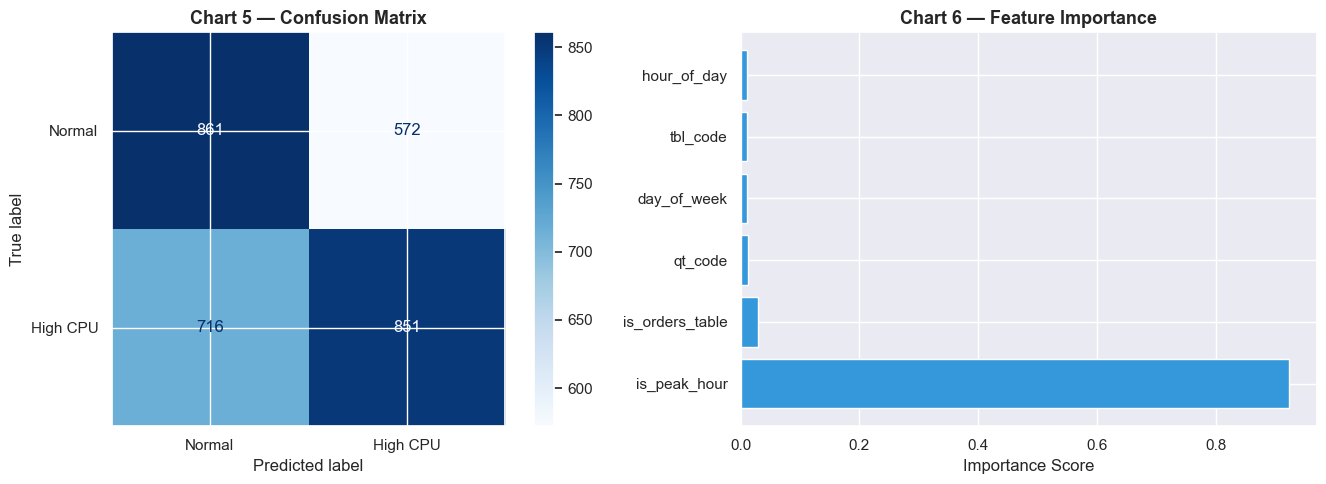

Charts 5-6 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Normal", "High CPU"],
    cmap="Blues", ax=axes[0])
axes[0].set_title("Chart 5 — Confusion Matrix", fontsize=13, fontweight="bold")

# Feature importance
importances = model.feature_importances_
feat_df = (pl.DataFrame({"feature": FEATURES, "importance": importances.tolist()})
             .sort("importance", descending=True))
axes[1].barh(feat_df["feature"].to_list(), feat_df["importance"].to_list(),
             color="#3498db", edgecolor="white")
axes[1].set_title("Chart 6 — Feature Importance", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig(f"{FIGURES}/chart5_6_model_results.png", dpi=150)
plt.show()
print("Charts 5-6 saved.")


In [7]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print("=" * 55)
print("  XGBOOST CPU SPIKE PREDICTOR — SUMMARY")
print("=" * 55)
print(f"  Features used    : {FEATURES}")
print(f"  Test accuracy    : {acc:.2%}")
print(f"  ROC-AUC          : {auc:.4f}")
print(f"  Model size       : {model.n_estimators} trees, depth {model.max_depth}")
print("=" * 55)


  XGBOOST CPU SPIKE PREDICTOR — SUMMARY
  Features used    : ['hour_of_day', 'day_of_week', 'is_peak_hour', 'is_orders_table', 'qt_code', 'tbl_code']
  Test accuracy    : 57.07%
  ROC-AUC          : 0.5960
  Model size       : 300 trees, depth 5
